# Melate, Revancha y Revanchita: análisis exploratorio (EDA)

**Fuente:** [resultadosmelate.mx](https://resultadosmelate.mx/melate-revancha-revanchita-historico), una página por concurso, descargada con `src/scraper.py` → `data/processed/melate_historico.csv`.

**Objetivo:** entender la historia completa de los sorteos y, antes de construir cualquier modelo predictivo, medir con pruebas estadísticas si los resultados se distinguen de un sorteo perfectamente aleatorio. Si no se distinguen, ningún modelo puede subir la probabilidad de acertar. En ese caso el modelo sirve para otras cosas: evaluar estrategias con rigor y elegir combinaciones poco jugadas, para no compartir el premio.

**Cómo leer las pruebas:** la hipótesis nula (H₀) siempre es *"el sorteo es uniforme e independiente"*. Un p-valor bajo (< 0.05) sería evidencia en contra. Con decenas de pruebas, algunos p-valores bajos aparecen por azar (≈1 de cada 20), así que se buscan patrones consistentes, no casos aislados.

### Resumen de hallazgos
- **Datos:** 9,441 sorteos: Melate 4,273 (desde el concurso 1, 19/08/1984), Revancha 3,265 (desde el concurso 1009, 1997) y Revanchita 1,903 (desde el concurso 2371, 2010), hasta el concurso 4273 (02/10/2026). Sin huecos, duplicados ni valores imposibles.
- **El juego cambió 4 veces de reglas:** 1–39 → 1–44 (1993) → 1–47 (2002) → 1–51 (2005) → **1–56 desde el concurso 2089 (12/12/2007)**. El análisis usa ese régimen: 6,273 sorteos entre los tres juegos.
- **Ninguna prueba encontró desviaciones del azar:** frecuencias por número, número adicional, atrasos, suma, pares/impares, altos/bajos, consecutivos, parejas, orden de extracción, repetición respecto al sorteo anterior y autocorrelación. Todos los p-valores son compatibles con un sorteo justo.
- **Los números "calientes" no persisten:** la frecuencia de un número en la primera mitad del régimen no predice la de la segunda (ρ ≈ 0), y en un backtest de ~17,500 jugadas por estrategia ninguna (calientes, fríos, atrasados, repetir el anterior) superó al azar.
- **Implicación para el modelo:** no hay señal que un modelo pueda aprender para acertar más números. El valor está en otras metas (ver Conclusiones).

In [1]:
import sys
from math import comb
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from statsmodels.tsa.stattools import acf

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import estilo
from estilo import COLORES, TEORICO, MUTED, TINTA_2, AZUL_SEQ, DIVERGENTE

estilo.aplicar()
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
rng = np.random.default_rng(2026)

JUEGOS = list(COLORES)
N_COLS = [f"n{i}" for i in range(1, 7)]   # números ordenados de menor a mayor
R_COLS = [f"r{i}" for i in range(1, 7)]   # números en el orden publicado (orden de extracción cuando existe)
K = 6


def guardar(fig, nombre):
    fig.savefig(FIG_DIR / f"{nombre}.png")


df = pd.read_csv(ROOT / "data" / "processed" / "melate_historico.csv", parse_dates=["fecha"])
df["juego"] = pd.Categorical(df["juego"], JUEGOS, ordered=True)
df = df.sort_values(["concurso", "juego"]).reset_index(drop=True)
df.head()

,concurso,fecha,juego,n1,n2,n3,n4,n5,n6,adicional,r1,r2,r3,r4,r5,r6,bolsa
0,1,1984-08-19,Melate,1,4,7,11,19,30,36.0,1,4,7,11,19,30,NaN
1,2,1984-08-26,Melate,5,6,24,30,34,38,32.0,5,6,24,30,34,38,NaN
2,3,1984-09-02,Melate,16,18,19,21,29,32,27.0,16,18,19,21,29,32,NaN
3,4,1984-09-09,Melate,8,12,15,18,20,34,37.0,8,12,15,18,20,34,NaN
4,5,1984-09-16,Melate,4,10,13,18,33,39,11.0,4,10,13,18,33,39,NaN


## 1. Calidad de los datos
Antes de analizar, se valida que no haya concursos faltantes, números repetidos dentro de un sorteo, valores fuera de rango ni fechas desordenadas.

In [2]:
resumen = df.groupby("juego", observed=True).agg(
    sorteos=("concurso", "size"),
    primer_concurso=("concurso", "min"),
    ultimo_concurso=("concurso", "max"),
    desde=("fecha", "min"),
    hasta=("fecha", "max"),
)
resumen

,sorteos,primer_concurso,ultimo_concurso,desde,hasta
juego,,,,,
Melate,4273,1,4273,1984-08-19,2026-10-02
Revancha,3265,1009,4273,1997-08-06,2026-10-02
Revanchita,1903,2371,4273,2010-08-25,2026-10-02


In [3]:
mel = df[df.juego == "Melate"].sort_values("concurso")
esperados = set(range(mel.concurso.min(), mel.concurso.max() + 1))
adic_dup = mel.apply(lambda r: r["adicional"] in set(r[N_COLS]), axis=1).sum()

checks = pd.Series({
    "Filas duplicadas (concurso, juego)": df.duplicated(["concurso", "juego"]).sum(),
    "Concursos faltantes en la secuencia de Melate": len(esperados - set(mel.concurso)),
    "Sorteos con algún número repetido": (df[N_COLS].nunique(axis=1) < K).sum(),
    "Melate: adicional igual a un número principal": adic_dup,
    "Números fuera de 1..56": ((df[N_COLS] < 1) | (df[N_COLS] > 56)).any(axis=1).sum(),
    "Melate: adicional faltante": mel.adicional.isna().sum(),
    "Fechas que no avanzan entre concursos": (mel.fecha.diff().dt.days <= 0).sum(),
    "Revancha/Revanchita en un concurso sin Melate": (~df.concurso.isin(mel.concurso)).sum(),
}, name="casos")
checks.to_frame()

,casos
"Filas duplicadas (concurso, juego)",0
Concursos faltantes en la secuencia de Melate,0
Sorteos con algún número repetido,0
Melate: adicional igual a un número principal,0
Números fuera de 1..56,0
Melate: adicional faltante,0
Fechas que no avanzan entre concursos,3
Revancha/Revanchita en un concurso sin Melate,0


In [4]:
# Detalle de las fechas que no avanzan (errores de captura en la fuente; el análisis usa el número de concurso como eje de tiempo)
i = np.flatnonzero((mel.fecha.diff().dt.days <= 0).to_numpy())
mel.iloc[np.unique(np.r_[i - 1, i, i + 1])][["concurso", "fecha"]]

,concurso,fecha
952,953,1997-01-26
953,954,1997-01-26
954,955,1997-01-29
1050,1030,1997-10-22
1052,1031,1997-10-22
1054,1032,1997-10-26
7341,3574,2022-04-20
7344,3575,2022-04-17
7347,3576,2022-04-20


In [5]:
# Bolsa: el sitio publica $0 cuando no tiene el dato. Antes de 1993 las cifras están en "pesos viejos" (1 N$ = 1,000 $).
bolsa = (df.assign(anio=df.fecha.dt.year)
           .groupby(["anio", "juego"], observed=True)["bolsa"]
           .apply(lambda s: s.notna().mean())
           .unstack())
print("Proporción de sorteos con bolsa publicada, por año (cada 3 años):")
bolsa.iloc[::3].map(lambda v: "—" if pd.isna(v) else f"{v:.0%}")

Proporción de sorteos con bolsa publicada, por año (cada 3 años):


juego,Melate,Revancha,Revanchita
anio,,,
1984,0%,—,—
1987,15%,—,—
1990,100%,—,—
1993,100%,—,—
1996,100%,—,—
1999,100%,100%,—
2002,100%,100%,—
2005,100%,100%,—
2008,98%,98%,—


**Lectura:** la base está completa y es consistente. Notas:
- El sitio publica sin números los concursos **4161–4163** (enero 2026). Se completaron a mano desde [melaterevancha.com](https://www.melaterevancha.com) (`data/raw/parches_manuales.csv`), después de verificar que esa fuente coincide en el concurso 4160.
- Hay 3 fechas mal capturadas en la fuente (dos concursos con la misma fecha en 1997 y el 3575 fechado antes que el 3574). No afectan nada, porque el análisis ordena por número de concurso.
- La **bolsa** solo está disponible entre 1987 y finales de 2022. Desde 2023 el sitio publica $0, así que no se usa en modelos.

## 2. Línea de tiempo: cuántos sorteos y qué días

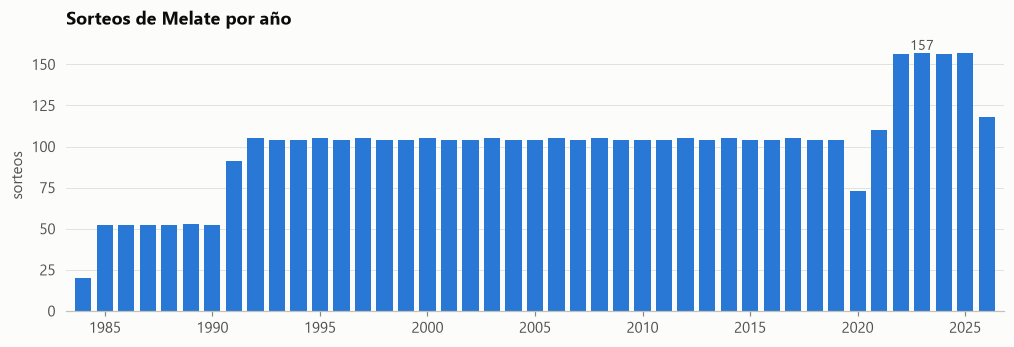

día,Mié,Jue,Vie,Dom
quinquenio,,,,
1980,0,0,0,20
1985,0,0,0,261
1990,195,1,0,260
1995,261,0,0,261
2000,261,0,0,261
2005,261,0,0,261
2010,261,0,0,261
2015,260,0,0,261
2020,246,0,161,245


In [6]:
por_anio = mel.groupby(mel.fecha.dt.year).size()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(por_anio.index, por_anio.values, color=COLORES["Melate"], width=0.75)
ax.set_title("Sorteos de Melate por año")
ax.set_ylabel("sorteos")
ax.margins(x=0.01)
for anio in (por_anio.idxmax(),):
    ax.annotate(f"{por_anio.max()}", (anio, por_anio.max()), ha="center", va="bottom", fontsize=9, color=TINTA_2)
guardar(fig, "01_sorteos_por_anio")
plt.show()

DIAS = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
dias = pd.crosstab((mel.fecha.dt.year // 5 * 5).rename("quinquenio"), mel.fecha.dt.dayofweek.map(dict(enumerate(DIAS))).rename("día"))
dias = dias.reindex(columns=[d for d in DIAS if d in dias.columns])
dias

In [7]:
inicio_juegos = df.groupby("juego", observed=True).agg(primer_concurso=("concurso", "min"), fecha=("fecha", "min"))
inicio_juegos

,primer_concurso,fecha
juego,,
Melate,1,1984-08-19
Revancha,1009,1997-08-06
Revanchita,2371,2010-08-25


**Lectura:** el Melate empezó con un sorteo semanal (domingo). Hacia 1990 pasó a dos por semana (miércoles y domingo) y desde 2020 hay tres (miércoles, viernes y domingo), por eso los últimos años tienen ~156 sorteos. La Revancha se agregó en 1997 y la Revanchita en 2010.

## 3. Cambios de reglas: ¿de cuántos números se elige?
El rango de números del Melate no siempre fue 1–56. Se detecta cada cambio buscando los *récords*: concursos donde sale un número mayor que cualquiera visto antes. Los récords llegan en ráfagas justo después de un cambio de reglas; cada ráfaga separada por más de 60 concursos marca un régimen nuevo. El análisis estadístico se hace **solo con el régimen vigente**, porque mezclar rangos distintos sesga las frecuencias hacia los números bajos.

In [8]:
def detectar_regimenes(d, separacion=60):
    d = d.sort_values("concurso")
    bolas = d[N_COLS].copy()
    if d["adicional"].notna().any():
        bolas["adicional"] = d["adicional"]
    maximos = bolas.max(axis=1).to_numpy()
    conc = d["concurso"].to_numpy()
    previo = np.maximum.accumulate(np.r_[0, maximos[:-1]])
    records = conc[maximos > previo]
    inicios = [records[0]] + [b for a, b in zip(records[:-1], records[1:]) if b - a > separacion]
    filas = []
    for i, ini in enumerate(inicios):
        fin = inicios[i + 1] - 1 if i + 1 < len(inicios) else conc.max()
        tramo = d[(d.concurso >= ini) & (d.concurso <= fin)]
        filas.append({"desde_concurso": ini, "hasta_concurso": fin,
                      "desde_fecha": tramo.fecha.min().date(), "hasta_fecha": tramo.fecha.max().date(),
                      "rango": f"1–{int(bolas.loc[tramo.index].max().max())}",
                      "N": int(bolas.loc[tramo.index].max().max()), "sorteos": len(tramo)})
    return pd.DataFrame(filas)


regimenes = detectar_regimenes(mel)
regimenes

,desde_concurso,hasta_concurso,desde_fecha,hasta_fecha,rango,N,sorteos
0,1,556,1984-08-19,1993-04-04,1–39,39,556
1,557,1547,1993-04-07,2002-10-02,1–44,44,991
2,1548,1877,2002-10-06,2005-11-30,1–47,47,330
3,1878,2088,2005-12-04,2007-12-09,1–51,51,211
4,2089,4273,2007-12-12,2026-10-02,1–56,56,2185


In [9]:
# Comprobación: el rango debe coincidir en Revancha y Revanchita
for juego in ["Revancha", "Revanchita"]:
    print(juego)
    print(detectar_regimenes(df[df.juego == juego])[["desde_concurso", "hasta_concurso", "rango", "sorteos"]].to_string(index=False), "\n")

Revancha
 desde_concurso  hasta_concurso rango  sorteos
           1009            1547  1–44      539
           1548            1878  1–47      331
           1879            2088  1–51      210
           2089            4273  1–56     2185 

Revanchita
 desde_concurso  hasta_concurso rango  sorteos
           2371            4273  1–56     1903 



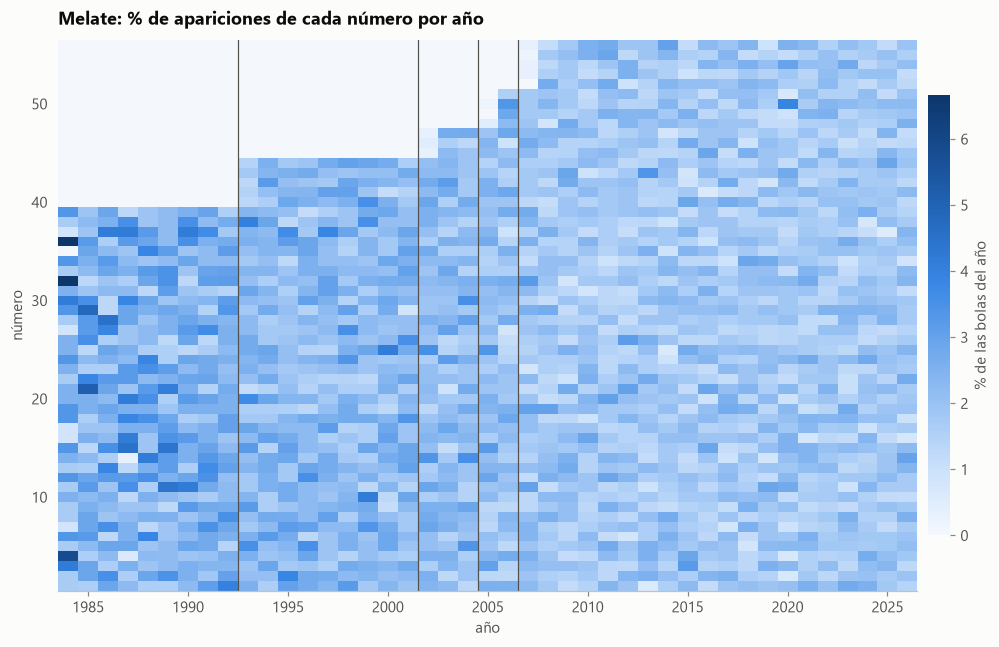

In [10]:
# Frecuencia relativa de cada número por año (Melate). Los cambios de rango se ven como bandas que "se encienden".
mat = (mel.melt(id_vars="fecha", value_vars=N_COLS, value_name="num")
          .assign(anio=lambda x: x.fecha.dt.year)
          .pipe(lambda x: pd.crosstab(x.num, x.anio)))
mat = mat / mel.groupby(mel.fecha.dt.year).size() / K * 100  # % de las bolas de ese año

fig, ax = plt.subplots(figsize=(12, 6.5))
im = ax.imshow(mat.values, aspect="auto", cmap=AZUL_SEQ, origin="lower",
               extent=[mat.columns.min() - 0.5, mat.columns.max() + 0.5, 0.5, mat.index.max() + 0.5])
ax.set_title("Melate: % de apariciones de cada número por año")
ax.set_xlabel("año"); ax.set_ylabel("número")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.01)
cb.set_label("% de las bolas del año", color=TINTA_2); cb.outline.set_visible(False)
for _, r in regimenes.iloc[1:].iterrows():
    ax.axvline(pd.Timestamp(r.desde_fecha).year - 0.5, color=TINTA_2, lw=0.8)
guardar(fig, "02_heatmap_numero_anio")
plt.show()

In [11]:
ACTUAL = regimenes.iloc[-1]
N = int(ACTUAL.N)
INICIO = int(ACTUAL.desde_concurso)
act = df[df.concurso >= INICIO].copy()
p = K / N
print(f"Régimen vigente: números 1–{N}, desde el concurso {INICIO} ({ACTUAL.desde_fecha}).")
print(act.groupby("juego", observed=True).size().rename("sorteos en el régimen vigente").to_string())

Régimen vigente: números 1–56, desde el concurso 2089 (2007-12-12).
juego
Melate        2185
Revancha      2185
Revanchita    1903


**Lectura:** el detector encontró 5 regímenes, y Revancha y Revanchita coinciden con el de Melate (la diferencia de un concurso en 1877/1878 es solo el momento en que apareció el primer número nuevo). En el heatmap se ven las bandas que se "encienden" al ampliarse el rango. También se ve que, dentro de cada régimen, la intensidad es pareja entre números, sin franjas persistentes.

**Decisión:** todo lo que sigue usa el régimen **1–56 (concurso 2089 en adelante)**: 2,185 sorteos de Melate, 2,185 de Revancha y 1,903 de Revanchita. Mezclar regímenes daría la falsa impresión de que los números bajos "salen más", solo porque existieron más tiempo.

## 4. Frecuencia de cada número (régimen vigente)
Si el sorteo es justo, cada número aparece en promedio en `T·6/N` sorteos, con una dispersión binomial. La banda gris marca el rango esperado al 95% **para un número dado**; la línea punteada exterior es el límite corregido por comparar 56 números a la vez (Bonferroni). Que algún número rebase la banda del 95% es normal: se esperan ~3 de 56.

La prueba global es una χ² de bondad de ajuste. Como cada sorteo saca 6 números *sin reemplazo*, la χ² clásica no aplica directamente, así que el p-valor se calcula por **simulación Monte Carlo** (3,000 historias simuladas de un sorteo perfectamente justo, con el mismo número de sorteos).

In [12]:
def frecuencias(d, cols=N_COLS, n=None):
    n = n or N
    v = d[cols].to_numpy().ravel()
    v = v[~pd.isna(v)].astype(int)
    return pd.Series(np.bincount(v, minlength=n + 1)[1:], index=pd.RangeIndex(1, n + 1, name="número"))


def simular_conteos(T, n=None, k=K, sims=3000, rng=rng):
    """Conteos por número de `sims` historias de T sorteos justos de k números sin reemplazo."""
    n = n or N
    out = np.empty((sims, n))
    for s in range(sims):
        idx = rng.random((T, n)).argpartition(k, axis=1)[:, :k]
        out[s] = np.bincount(idx.ravel(), minlength=n)
    return out


def chi2_pearson(conteos, esperado):
    return ((conteos - esperado) ** 2 / esperado).sum(axis=-1)


resultados_freq = []
sims_cache = {}
for juego in JUEGOS:
    d = act[act.juego == juego]
    T = len(d)
    obs = frecuencias(d).to_numpy()
    e = T * p
    sims_cache[juego] = simular_conteos(T)
    chi_obs = chi2_pearson(obs, e)
    chi_sim = chi2_pearson(sims_cache[juego], e)
    resultados_freq.append({
        "juego": juego, "sorteos": T, "esperado por número": round(e, 1),
        "mín observado": obs.min(), "máx observado": obs.max(),
        "χ²": round(chi_obs, 1), "p-valor (Monte Carlo)": (chi_sim >= chi_obs).mean(),
        "números fuera de banda 95%": int((np.abs(obs - e) > 1.96 * np.sqrt(T * p * (1 - p))).sum()),
    })
pd.DataFrame(resultados_freq).set_index("juego")

,sorteos,esperado por número,mín observado,máx observado,χ²,p-valor (Monte Carlo),números fuera de banda 95%
juego,,,,,,,
Melate,2185,234.1,207,261,47.9,0.572333,0
Revancha,2185,234.1,208,255,38.5,0.900333,0
Revanchita,1903,203.9,177,235,50.2,0.461000,3


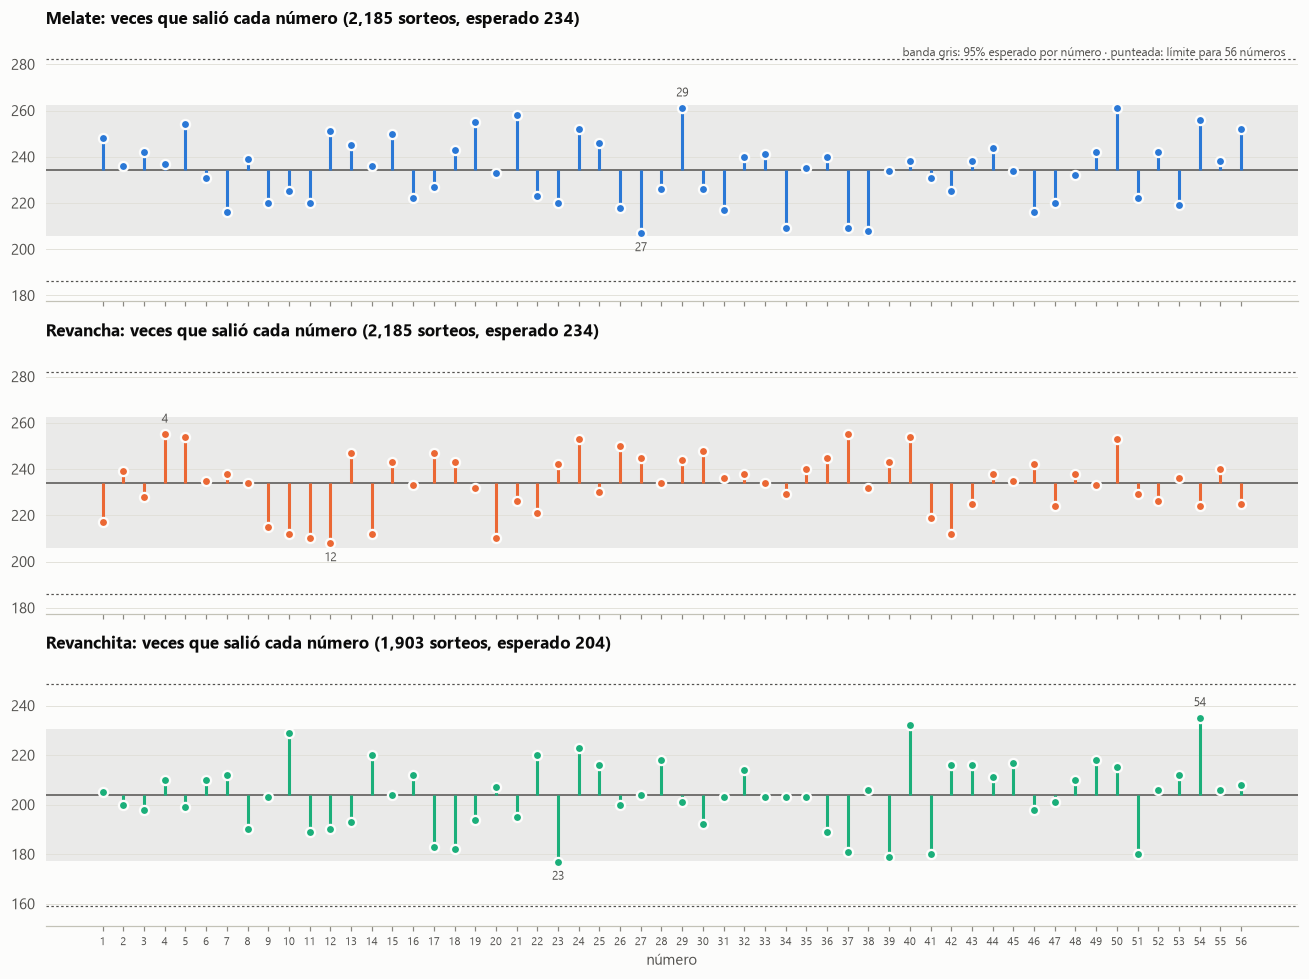

In [13]:
z_bonf = stats.norm.ppf(1 - 0.025 / N)
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, juego in zip(axes, JUEGOS):
    d = act[act.juego == juego]
    T = len(d); e = T * p; sd = np.sqrt(T * p * (1 - p))
    f = frecuencias(d)
    # Lollipop desde el valor esperado: muestra la desviación sin truncar barras.
    ax.axhspan(e - 1.96 * sd, e + 1.96 * sd, color=TEORICO, alpha=0.10, lw=0, zorder=0)
    ax.axhline(e, color=TEORICO, lw=1, zorder=1)
    for s in (-1, 1):
        ax.axhline(e + s * z_bonf * sd, color=TEORICO, lw=0.8, ls=(0, (2, 2)), zorder=1)
    ax.vlines(f.index, e, f.values, color=COLORES[juego], lw=2, zorder=2)
    ax.plot(f.index, f.values, "o", ms=6, color=COLORES[juego], mec="#fcfcfb", mew=1.5, zorder=3)
    ax.set_ylim(e - (z_bonf + 0.6) * sd, e + (z_bonf + 0.6) * sd)
    ax.set_title(f"{juego}: veces que salió cada número ({T:,} sorteos, esperado {e:.0f})", fontsize=11)
    for n_, va, dy in ((f.idxmax(), "bottom", 6), (f.idxmin(), "top", -6)):
        ax.annotate(f"{n_}", (n_, f[n_]), xytext=(0, dy), textcoords="offset points", ha="center", va=va, fontsize=8, color=TINTA_2)
axes[0].annotate("banda gris: 95% esperado por número · punteada: límite para 56 números", (0.99, 0.97),
                 xycoords="axes fraction", ha="right", va="top", fontsize=8, color=TINTA_2)
axes[-1].set_xticks(range(1, N + 1))
axes[-1].tick_params(axis="x", labelsize=7.5)
axes[-1].set_xlabel("número")
fig.tight_layout()
guardar(fig, "03_frecuencias_por_numero")
plt.show()

In [14]:
tabla = []
for juego in JUEGOS:
    d = act[act.juego == juego]
    f = frecuencias(d)
    z = (f - len(d) * p) / np.sqrt(len(d) * p * (1 - p))
    tabla.append(pd.DataFrame({
        "más frecuentes": [f"{n} ({f[n]}, z={z[n]:+.1f})" for n in f.nlargest(5).index],
        "menos frecuentes": [f"{n} ({f[n]}, z={z[n]:+.1f})" for n in f.nsmallest(5).index],
    }).set_axis(pd.MultiIndex.from_product([[juego], ["más frecuentes", "menos frecuentes"]]), axis=1))
pd.concat(tabla, axis=1)

Melate                            Revancha                          Revanchita                  
     más frecuentes  menos frecuentes    más frecuentes  menos frecuentes    más frecuentes  menos frecuentes
0  29 (261, z=+1.9)  27 (207, z=-1.9)   4 (255, z=+1.4)  12 (208, z=-1.8)  54 (235, z=+2.3)  23 (177, z=-2.0)
1  50 (261, z=+1.9)  38 (208, z=-1.8)  37 (255, z=+1.4)  11 (210, z=-1.7)  40 (232, z=+2.1)  39 (179, z=-1.8)
2  21 (258, z=+1.7)  34 (209, z=-1.7)   5 (254, z=+1.4)  20 (210, z=-1.7)  10 (229, z=+1.9)  41 (180, z=-1.8)
3  54 (256, z=+1.5)  37 (209, z=-1.7)  40 (254, z=+1.4)  10 (212, z=-1.5)  24 (223, z=+1.4)  51 (180, z=-1.8)
4  19 (255, z=+1.4)   7 (216, z=-1.3)  24 (253, z=+1.3)  14 (212, z=-1.5)  14 (220, z=+1.2)  37 (181, z=-1.7)

In [15]:
# Número adicional (solo Melate): se extrae de los 50 restantes, así que su distribución marginal también es uniforme 1/N.
ad = act[act.juego == "Melate"]["adicional"].astype(int)
obs_ad = np.bincount(ad, minlength=N + 1)[1:]
chi_ad, p_ad = stats.chisquare(obs_ad)
print(f"Adicional: {len(ad)} sorteos, esperado {len(ad)/N:.1f} por número, rango observado {obs_ad.min()}–{obs_ad.max()}, χ²={chi_ad:.1f}, p={p_ad:.3f}")

Adicional: 2185 sorteos, esperado 39.0 por número, rango observado 25–57, χ²=70.0, p=0.083


**Lectura:**
- En Melate, el número más frecuente (29 y 50, con 261) y el menos frecuente (27, con 207) están dentro de lo esperado por azar para 56 números (z ≈ ±1.9). **Ningún número rebasa el límite corregido** en ninguno de los tres juegos.
- Las χ² globales dan p-valores de ~0.57 (Melate), ~0.90 (Revancha) y ~0.46 (Revanchita): las diferencias de frecuencia son del tamaño exacto que produce el azar.
- En Revanchita, 3 números quedan fuera de la banda del 95%, justo lo esperado (56 × 5% ≈ 2.8).
- El número adicional también es uniforme (p ≈ 0.08).

## 5. ¿Los números "calientes" siguen calientes?
Esta es la pregunta clave para un modelo predictivo. Si hubiera un sesgo físico real (bolas más pesadas, una máquina defectuosa), los números frecuentes en un periodo también lo serían en el siguiente, y en los tres juegos a la vez.

**5a. Persistencia:** correlación de Spearman entre la frecuencia de cada número en la primera y en la segunda mitad del régimen, y entre juegos.

In [16]:
filas = []
for juego in JUEGOS:
    d = act[act.juego == juego].sort_values("concurso")
    mitad = len(d) // 2
    rho, pv = stats.spearmanr(frecuencias(d.iloc[:mitad]), frecuencias(d.iloc[mitad:]))
    filas.append({"comparación": f"{juego}: 1ª mitad vs 2ª mitad", "ρ Spearman": rho, "p-valor": pv})
for a, b in [("Melate", "Revancha"), ("Melate", "Revanchita"), ("Revancha", "Revanchita")]:
    rho, pv = stats.spearmanr(frecuencias(act[act.juego == a]), frecuencias(act[act.juego == b]))
    filas.append({"comparación": f"{a} vs {b}", "ρ Spearman": rho, "p-valor": pv})
pd.DataFrame(filas).set_index("comparación").round(3)

,ρ Spearman,p-valor
comparación,,
Melate: 1ª mitad vs 2ª mitad,-0.186,0.170
Revancha: 1ª mitad vs 2ª mitad,-0.024,0.861
Revanchita: 1ª mitad vs 2ª mitad,0.072,0.596
Melate vs Revancha,0.046,0.736
Melate vs Revanchita,0.107,0.431
Revancha vs Revanchita,-0.181,0.181


**5b. Backtest de estrategias populares.** Para cada sorteo se eligen 6 números usando *solo* la historia anterior, y se cuentan los aciertos. Al azar, el promedio esperado es 6·6/56 ≈ **0.643** aciertos por sorteo.
- *Calientes*: los 6 más frecuentes en los últimos W sorteos.
- *Fríos*: los 6 menos frecuentes en los últimos W sorteos.
- *Atrasados*: los 6 que llevan más sorteos sin salir.
- *Repetir el anterior*: los 6 del sorteo previo.
- *Al azar*: 6 números aleatorios (control).

In [17]:
def backtest(d, W):
    M = np.zeros((len(d), N + 1), dtype=np.int8)
    nums = d[N_COLS].to_numpy()
    M[np.arange(len(d))[:, None], nums] = 1
    M = M[:, 1:]
    acum = np.vstack([np.zeros(N), np.cumsum(M, axis=0)])
    ultimo = np.full(N, -1)
    res = {k: [] for k in ["Calientes", "Fríos", "Atrasados", "Repetir el anterior", "Al azar"]}
    for t in range(len(d)):
        if t >= W:
            ventana = acum[t] - acum[t - W]
            orden = np.lexsort((rng.random(N), ventana))  # desempate aleatorio
            elegidos = {
                "Calientes": orden[-K:],
                "Fríos": orden[:K],
                "Atrasados": np.lexsort((rng.random(N), -ultimo))[-K:],
                "Repetir el anterior": np.flatnonzero(M[t - 1]),
                "Al azar": rng.choice(N, K, replace=False),
            }
            for k, sel in elegidos.items():
                res[k].append(M[t, sel].sum())
        ultimo[M[t] == 1] = t
    return res


esperado_aciertos = K * K / N
filas = []
for W in (25, 100, 300):
    agregados = {}
    for juego in JUEGOS:
        r = backtest(act[act.juego == juego].sort_values("concurso"), W)
        for k, v in r.items():
            agregados.setdefault(k, []).extend(v)
    for k, v in agregados.items():
        v = np.asarray(v)
        t_stat, pv = stats.ttest_1samp(v, esperado_aciertos)
        filas.append({"ventana W": W, "estrategia": k, "jugadas": len(v), "aciertos promedio": v.mean(),
                      "IC 95%": f"{v.mean() - 1.96 * v.std(ddof=1) / np.sqrt(len(v)):.3f} – {v.mean() + 1.96 * v.std(ddof=1) / np.sqrt(len(v)):.3f}",
                      "% con ≥3 aciertos": (v >= 3).mean() * 100, "p-valor vs azar": pv})
bt = pd.DataFrame(filas)
print(f"Esperado al azar: {esperado_aciertos:.3f} aciertos;  P(≥3 aciertos) teórica = "
      f"{sum(comb(K, j) * comb(N - K, K - j) for j in range(3, 7)) / comb(N, K) * 100:.2f}%")
bt.round({"aciertos promedio": 3, "% con ≥3 aciertos": 2, "p-valor vs azar": 3})

Esperado al azar: 0.643 aciertos;  P(≥3 aciertos) teórica = 1.26%


,ventana W,estrategia,jugadas,aciertos promedio,IC 95%,% con ≥3 aciertos,p-valor vs azar
0,25,Calientes,6198,0.637,0.619 – 0.655,1.19,0.533
1,25,Fríos,6198,0.649,0.631 – 0.666,1.31,0.530
2,25,Atrasados,6198,0.653,0.635 – 0.672,1.45,0.253
3,25,Repetir el anterior,6198,0.643,0.625 – 0.661,1.36,0.978
4,25,Al azar,6198,0.638,0.620 – 0.656,1.26,0.578
5,100,Calientes,5973,0.640,0.622 – 0.658,1.09,0.761
6,100,Fríos,5973,0.652,0.634 – 0.671,1.17,0.314
7,100,Atrasados,5973,0.654,0.636 – 0.673,1.39,0.224
8,100,Repetir el anterior,5973,0.644,0.625 – 0.662,1.34,0.940
9,100,Al azar,5973,0.643,0.624 – 0.661,1.31,0.989


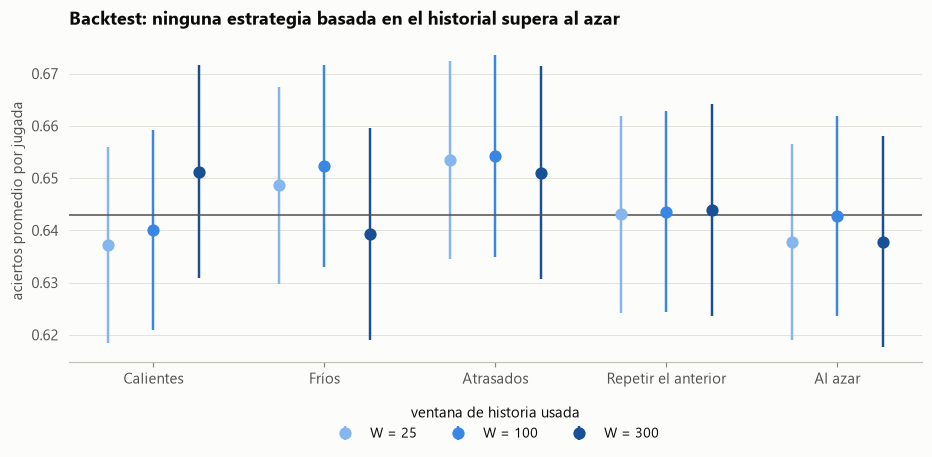

In [18]:
fig, ax = plt.subplots(figsize=(10, 3.8))
estrategias = bt.estrategia.unique()
ventanas = bt["ventana W"].unique()
ancho = 0.8 / len(ventanas)
tonos = ["#86b6ef", "#3987e5", "#184f95"]  # ordinal: ventana corta → larga
for i, W in enumerate(ventanas):
    sub = bt[bt["ventana W"] == W].set_index("estrategia").loc[estrategias]
    err = 1.96 * np.sqrt(sub["aciertos promedio"] * (1 - sub["aciertos promedio"] / K) / sub["jugadas"])
    x = np.arange(len(estrategias)) + (i - (len(ventanas) - 1) / 2) * ancho
    ax.errorbar(x, sub["aciertos promedio"], yerr=err, fmt="o", ms=7, color=tonos[i], capsize=0, lw=1.6, label=f"W = {W}")
ax.axhline(esperado_aciertos, color=TEORICO, lw=1)
ax.annotate("esperado al azar = 0.643", (len(estrategias) - 0.5, esperado_aciertos), xytext=(0, 4),
            textcoords="offset points", ha="right", fontsize=8.5, color=TINTA_2)
ax.set_xticks(range(len(estrategias)), estrategias)
ax.set_ylabel("aciertos promedio por jugada")
ax.set_title("Backtest: ninguna estrategia basada en el historial supera al azar")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncols=3, title="ventana de historia usada")
guardar(fig, "04_backtest_estrategias")
plt.show()

**Lectura:**
- **Persistencia nula:** las correlaciones entre mitades van de −0.19 a +0.07, ninguna significativa. Un número frecuente en la primera mitad (2007–2018) no lo fue más en la segunda (2018–2026). Entre juegos tampoco hay relación, lo que descarta un sesgo físico compartido (bolas o máquina).
- **Backtest:** todas las estrategias dan entre 0.637 y 0.654 aciertos por jugada, contra 0.643 esperado al azar, con p-valores de 0.22 a 0.99. El porcentaje de jugadas con 3 o más aciertos (~1.1–1.5%) también coincide con el teórico (1.26%).
- Esta es la evidencia más directa: **el historial no contiene información útil para elegir números.**

## 6. Atrasos: ¿cuántos sorteos pasan entre apariciones de un número?
En un sorteo justo, la espera entre apariciones de un número sigue una distribución **geométrica** con p = 6/N (≈10.7%): la espera promedio es N/6 ≈ 9.3 sorteos, y un atraso largo **no** hace más probable que el número salga en el próximo sorteo (falta de memoria).

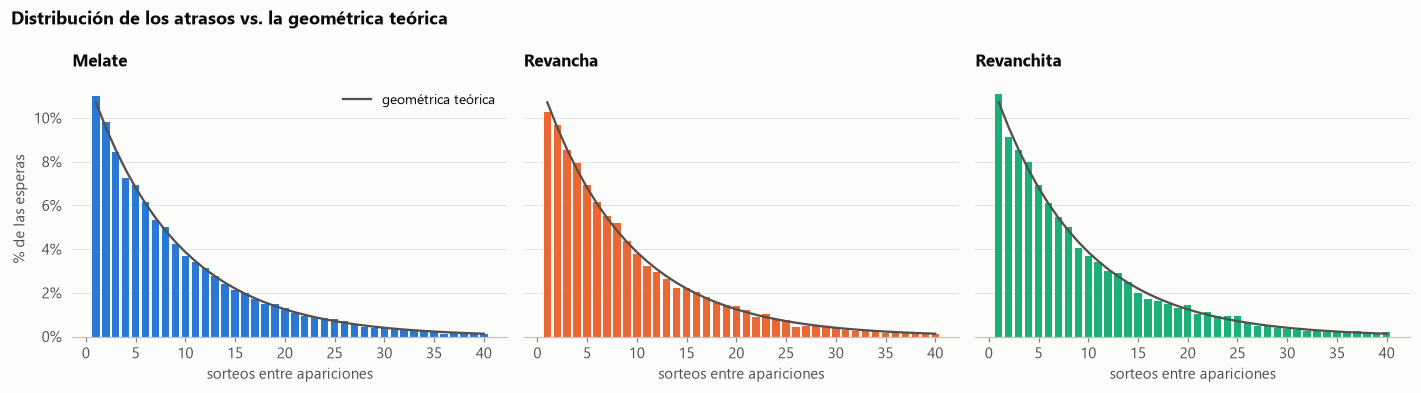

,esperas medidas,media observada,media teórica,máx observado,χ² (41 clases),p-valor
juego,,,,,,
Melate,13054,9.290,9.333,85,24.927,0.970
Revancha,13054,9.291,9.333,92,43.428,0.327
Revanchita,11362,9.293,9.333,95,51.576,0.104


In [19]:
def gaps_de(d):
    d = d.sort_values("concurso")
    M = np.zeros((len(d), N + 1), dtype=bool)
    M[np.arange(len(d))[:, None], d[N_COLS].to_numpy()] = True
    gaps = []
    for n_ in range(1, N + 1):
        pos = np.flatnonzero(M[:, n_])
        gaps.extend(np.diff(pos))
    return np.asarray(gaps)


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
filas = []
for ax, juego in zip(axes, JUEGOS):
    g = gaps_de(act[act.juego == juego])
    kmax = 40
    obs = np.bincount(np.minimum(g, kmax + 1), minlength=kmax + 2)[1:]
    teo_p = np.r_[[(1 - p) ** (k - 1) * p for k in range(1, kmax + 1)], (1 - p) ** kmax]
    chi, pv = stats.chisquare(obs, teo_p * len(g))
    filas.append({"juego": juego, "esperas medidas": len(g), "media observada": g.mean(), "media teórica": 1 / p,
                  "máx observado": g.max(), "χ² (41 clases)": chi, "p-valor": pv})
    ax.bar(np.arange(1, kmax + 1), obs[:-1] / len(g), color=COLORES[juego], width=0.75)
    ax.plot(np.arange(1, kmax + 1), teo_p[:-1], color=TEORICO, lw=1.5, label="geométrica teórica")
    ax.set_title(juego, fontsize=11)
    ax.set_xlabel("sorteos entre apariciones")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=0))
axes[0].set_ylabel("% de las esperas")
axes[0].legend()
fig.suptitle("Distribución de los atrasos vs. la geométrica teórica", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
guardar(fig, "05_atrasos")
plt.show()
pd.DataFrame(filas).set_index("juego").round(3)

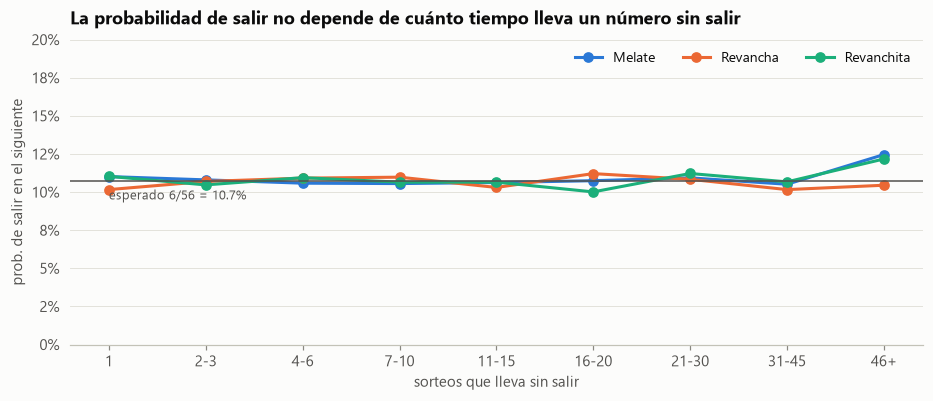

juego,n Melate,n Revancha,n Revanchita
atraso_grupo,,,
1,12744,12744,11052
2-3,21436,21662,18653
4-6,24353,24501,21134
7-10,21968,21856,18904
11-15,16704,16530,14347
16-20,9539,9456,8381
21-30,8343,8102,7301
31-45,3263,3356,2887
46+,594,737,493


In [20]:
# ¿La probabilidad de salir depende del atraso? Si hubiera "deuda", la tasa subiría con el atraso.
filas = []
for juego in JUEGOS:
    d = act[act.juego == juego].sort_values("concurso")
    M = np.zeros((len(d), N + 1), dtype=bool)
    M[np.arange(len(d))[:, None], d[N_COLS].to_numpy()] = True
    M = M[:, 1:]
    ultimo = np.full(N, -1)
    for t in range(len(d)):
        if t > 60:
            atraso = t - ultimo
            for n_ in range(N):
                filas.append((juego, atraso[n_], M[t, n_]))
        ultimo[M[t]] = t
haz = pd.DataFrame(filas, columns=["juego", "atraso", "sale"])
haz["atraso_grupo"] = pd.cut(haz.atraso, [0, 1, 3, 6, 10, 15, 20, 30, 45, 1000],
                             labels=["1", "2-3", "4-6", "7-10", "11-15", "16-20", "21-30", "31-45", "46+"])
tasa = haz.groupby(["atraso_grupo", "juego"], observed=True)["sale"].agg(["mean", "size"]).unstack("juego")

fig, ax = plt.subplots(figsize=(10, 3.6))
for juego in JUEGOS:
    ax.plot(tasa.index.astype(str), tasa[("mean", juego)], marker="o", ms=6, color=COLORES[juego], label=juego)
ax.axhline(p, color=TEORICO, lw=1)
ax.annotate(f"esperado 6/{N} = {p:.1%}", (0, p), xytext=(0, -12), textcoords="offset points", fontsize=8.5, color=TINTA_2)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=0))
ax.set_ylim(0, 0.2)
ax.set_xlabel("sorteos que lleva sin salir"); ax.set_ylabel("prob. de salir en el siguiente")
ax.set_title("La probabilidad de salir no depende de cuánto tiempo lleva un número sin salir")
ax.legend(ncols=3, loc="upper right")
guardar(fig, "06_prob_vs_atraso")
plt.show()
tasa["size"].rename(columns=lambda c: f"n {c}")

**Lectura:** la espera media entre apariciones es 9.29 sorteos, contra 9.33 teórico, y la forma coincide con la geométrica (p = 0.97, 0.33 y 0.10). La segunda gráfica responde a la "ley de los promedios": un número que lleva 30 o 45 sorteos sin salir tiene la misma probabilidad de salir (~10.7%) que uno que salió ayer. El ligero repunte en "46+" se basa en pocos casos (~500–700) y cae dentro del ruido. **Las bolas no tienen memoria.**

## 7. Forma de la combinación ganadora
Características de las 6 bolas de cada sorteo comparadas con su distribución teórica (calculada simulando 300,000 combinaciones al azar de 6 de 56). Se juntan los tres juegos para tener más sorteos.

In [21]:
def rasgos(nums):
    nums = np.sort(nums, axis=1)
    dif = np.diff(nums, axis=1)
    return pd.DataFrame({
        "suma": nums.sum(axis=1),
        "pares": (nums % 2 == 0).sum(axis=1),
        f"bajos (≤{N // 2})": (nums <= N // 2).sum(axis=1),
        "parejas consecutivas": (dif == 1).sum(axis=1),
        "rango (mayor − menor)": nums[:, -1] - nums[:, 0],
        "decenas distintas": np.array([len(set(r)) for r in (nums // 10)]),
        "terminaciones distintas": np.array([len(set(r)) for r in (nums % 10)]),
    })


teo = rasgos(rng.random((300_000, N)).argpartition(K, axis=1)[:, :K] + 1)
obs = rasgos(act[N_COLS].to_numpy())

filas = []
for c in obs.columns:
    if obs[c].nunique() > 15:
        stat, pv = stats.ks_2samp(obs[c], teo[c])
        prueba = "KS"
    else:
        cats = sorted(set(teo[c]) | set(obs[c]))
        o = obs[c].value_counts().reindex(cats, fill_value=0)
        e = teo[c].value_counts(normalize=True).reindex(cats, fill_value=0) * len(obs)
        keep = e >= 5  # agrupa colas con esperados pequeños
        o = np.r_[o[keep].values, o[~keep].sum()] if (~keep).any() else o.values
        e = np.r_[e[keep].values, e[~keep].sum()] if (~keep).any() else e.values
        stat, pv = stats.chisquare(o, e * o.sum() / e.sum())
        prueba = "χ²"
    filas.append({"rasgo": c, "media observada": obs[c].mean(), "media teórica": teo[c].mean(), "prueba": prueba, "p-valor": pv})
pd.DataFrame(filas).set_index("rasgo").round(3)

,media observada,media teórica,prueba,p-valor
rasgo,,,,
suma,171.350,171.030,KS,0.847
pares,3.021,3.000,χ²,0.188
bajos (≤28),2.993,3.000,χ²,0.406
parejas consecutivas,0.535,0.536,χ²,0.690
rango (mayor − menor),40.806,40.741,KS,0.274
decenas distintas,4.083,4.086,χ²,0.832
terminaciones distintas,4.849,4.845,χ²,0.383


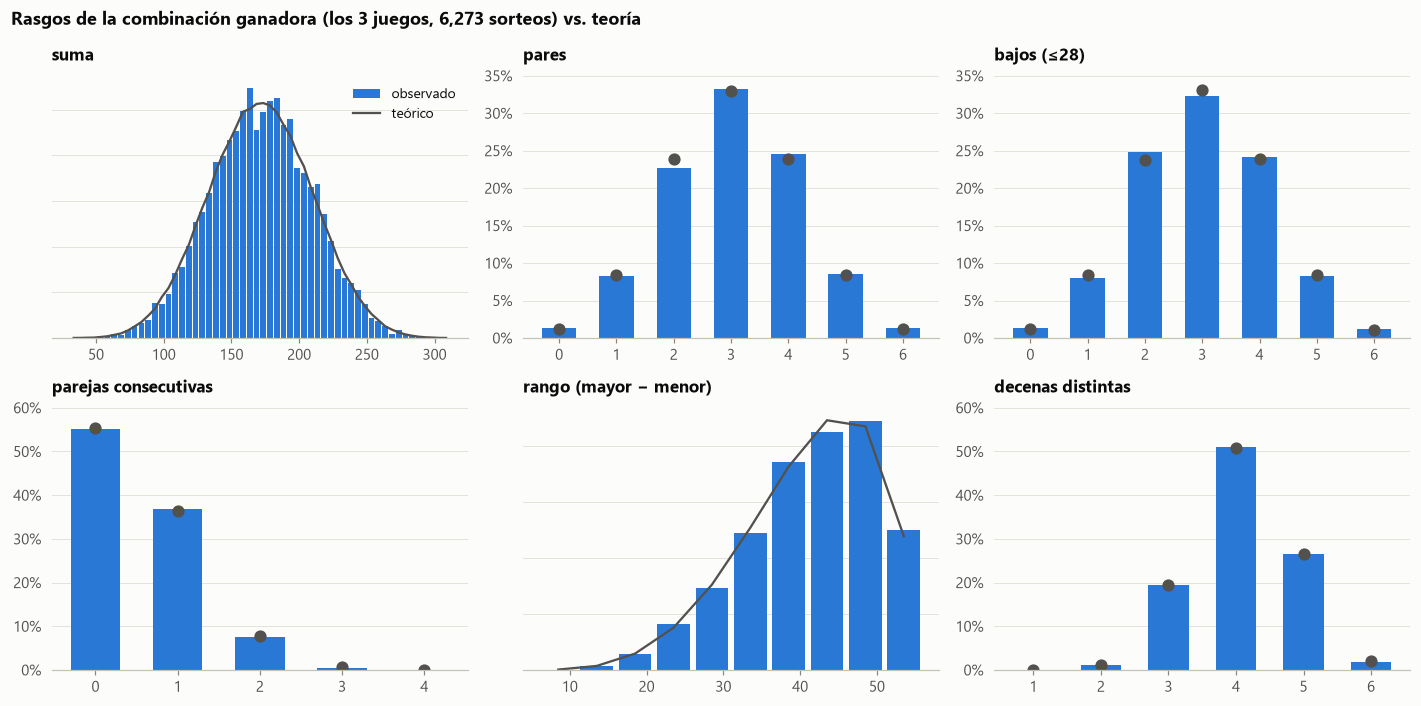

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, c in zip(axes.ravel(), ["suma", "pares", f"bajos (≤{N // 2})", "parejas consecutivas", "rango (mayor − menor)", "decenas distintas"]):
    if c in ("suma", "rango (mayor − menor)"):
        bins = np.arange(teo[c].min(), teo[c].max() + 6, 5)
        ax.hist(obs[c], bins=bins, density=True, color=COLORES["Melate"], rwidth=0.85, label="observado")
        h, edges = np.histogram(teo[c], bins=bins, density=True)
        ax.plot((edges[:-1] + edges[1:]) / 2, h, color=TEORICO, lw=1.5, label="teórico")
    else:
        cats = np.arange(teo[c].min(), teo[c].max() + 1)
        ax.bar(cats, obs[c].value_counts(normalize=True).reindex(cats, fill_value=0), color=COLORES["Melate"], width=0.6, label="observado")
        ax.plot(cats, teo[c].value_counts(normalize=True).reindex(cats, fill_value=0), "o", color=TEORICO, ms=7, label="teórico")
        ax.set_xticks(cats)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=0))
    ax.set_title(c, fontsize=11)
    ax.set_yticks(ax.get_yticks()) if c not in ("suma", "rango (mayor − menor)") else ax.set_yticklabels([])
axes[0, 0].legend()
fig.suptitle(f"Rasgos de la combinación ganadora (los 3 juegos, {len(obs):,} sorteos) vs. teoría", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
guardar(fig, "07_rasgos_combinacion")
plt.show()

In [23]:
# Estadísticos de orden: el k-ésimo número más pequeño tiene media teórica k·(N+1)/7
pos = pd.DataFrame({
    "posición": N_COLS,
    "media observada": act[N_COLS].mean().values,
    "media teórica": [k * (N + 1) / (K + 1) for k in range(1, K + 1)],
    "p-valor KS": [stats.ks_2samp(act[c], np.sort(rng.random((100_000, N)).argpartition(K, axis=1)[:, :K] + 1, axis=1)[:, i]).pvalue
                   for i, c in enumerate(N_COLS)],
}).set_index("posición")
pos.round(3)

,media observada,media teórica,p-valor KS
posición,,,
n1,8.156,8.143,0.929
n2,16.230,16.286,0.691
n3,24.487,24.429,0.783
n4,32.663,32.571,0.905
n5,40.853,40.714,0.442
n6,48.961,48.857,0.116


**Lectura:** todas las características de la combinación ganadora siguen su distribución teórica (p-valores de 0.19 a 0.85). La suma típica ronda 171, lo normal es 3 pares y 3 impares, y hay al menos una pareja de consecutivos en ~45% de los sorteos.

⚠️ **Cuidado con una trampa común:** que "3 pares/3 impares" o "suma entre 130 y 210" sean lo más frecuente **no** hace más probable ninguna combinación concreta. Simplemente hay muchas más combinaciones con esas características. Cada combinación individual tiene la misma probabilidad: 1 en 32,468,436.

## 8. Orden de extracción
En parte del histórico el sitio publica las bolas en el orden en que salieron (no ordenadas). Ahí se puede revisar si la *primera* bola extraída, la segunda, etc., favorecen ciertos números o valores.

In [24]:
# Un sorteo publicado de menor a mayor no revela el orden de extracción (un orden real sale creciente solo 1 de cada 720 veces).
df["orden_extraccion"] = ~(np.diff(df[R_COLS].to_numpy(), axis=1) > 0).all(axis=1)
prop = df.groupby(df.fecha.dt.year)["orden_extraccion"].mean()
print("Años con sorteos publicados en orden de extracción:")
print(prop[prop > 0].map("{:.0%}".format).to_string())
ext = df[df.orden_extraccion]
print(f"\nSorteos utilizables: {len(ext):,} (concursos {ext.concurso.min()}–{ext.concurso.max()}, los 3 juegos)")

Años con sorteos publicados en orden de extracción:
fecha
2020     62%
2021    100%
2022     80%

Sorteos utilizables: 840 (concursos 3374–3674, los 3 juegos)


In [25]:
filas = []
for i, c in enumerate(R_COLS, start=1):
    o = np.bincount(ext[c], minlength=N + 1)[1:]
    chi, pv = stats.chisquare(o)
    filas.append({"bola extraída": f"{i}ª", "media": ext[c].mean(), "media teórica": (N + 1) / 2, "χ² uniformidad": chi, "p-valor": pv})
pd.DataFrame(filas).set_index("bola extraída").round(3)

,media,media teórica,χ² uniformidad,p-valor
bola extraída,,,,
1ª,29.827,28.5,59.867,0.304
2ª,28.198,28.5,47.733,0.746
3ª,29.489,28.5,67.333,0.123
4ª,27.517,28.5,54.267,0.503
5ª,29.124,28.5,63.200,0.209
6ª,28.452,28.5,53.067,0.549


**Lectura:** el orden de extracción solo se publicó entre los concursos 3374 y 3674 (2020–2022): 840 sorteos en total. En ese periodo, la 1ª, 2ª, … 6ª bola extraída son uniformes en 1–56 (p de 0.12 a 0.75) y su media ronda 28.5. Ninguna posición del orden de extracción favorece números.

## 9. Parejas que salen juntas
Cada sorteo contiene 15 parejas. Para un par dado, el número esperado de sorteos en que aparecen juntos es `T·30/(N·(N−1))`. Se busca si hay parejas "amigas" (que salen juntas más de lo normal) usando el máximo observado contra el máximo de historias simuladas.

In [26]:
def matriz_parejas(nums, n=None):
    n = n or N
    C = np.zeros((n + 1, n + 1), dtype=int)
    for i in range(K):
        for j in range(i + 1, K):
            np.add.at(C, (nums[:, i], nums[:, j]), 1)
    C = C + C.T
    return C[1:, 1:]


nums_act = act[N_COLS].to_numpy()
T_all = len(nums_act)
P = matriz_parejas(nums_act)
e_par = T_all * K * (K - 1) / (N * (N - 1))
iu = np.triu_indices(N, 1)

max_sim = []
for _ in range(300):
    sim = np.sort(rng.random((T_all, N)).argpartition(K, axis=1)[:, :K] + 1, axis=1)
    Ps = matriz_parejas(sim)
    max_sim.append(Ps[iu].max())
max_sim = np.array(max_sim)

top = sorted(zip(P[iu], iu[0] + 1, iu[1] + 1), reverse=True)[:10]
print(f"{T_all:,} sorteos (3 juegos). Esperado por pareja: {e_par:.1f}. Máximo observado: {P[iu].max()}, "
      f"mínimo: {P[iu].min()}. p-valor del máximo (vs 300 simulaciones): {(max_sim >= P[iu].max()).mean():.2f}")
print(f"Desv. estándar de los conteos de parejas: observada {P[iu].std():.2f}, simulada típica {np.sqrt(e_par * (1 - e_par / T_all)):.2f}")
pd.DataFrame(top, columns=["veces juntas", "a", "b"]).assign(pareja=lambda x: x.a.astype(str) + "–" + x.b.astype(str))[["pareja", "veces juntas"]]

6,273 sorteos (3 juegos). Esperado por pareja: 61.1. Máximo observado: 95, mínimo: 36. p-valor del máximo (vs 300 simulaciones): 0.06
Desv. estándar de los conteos de parejas: observada 7.46, simulada típica 7.78


,pareja,veces juntas
0,13–22,95
1,24–32,87
2,24–28,86
3,1–5,86
4,26–35,85
5,50–52,83
6,38–50,83
7,4–40,83
8,40–45,82
9,15–40,82


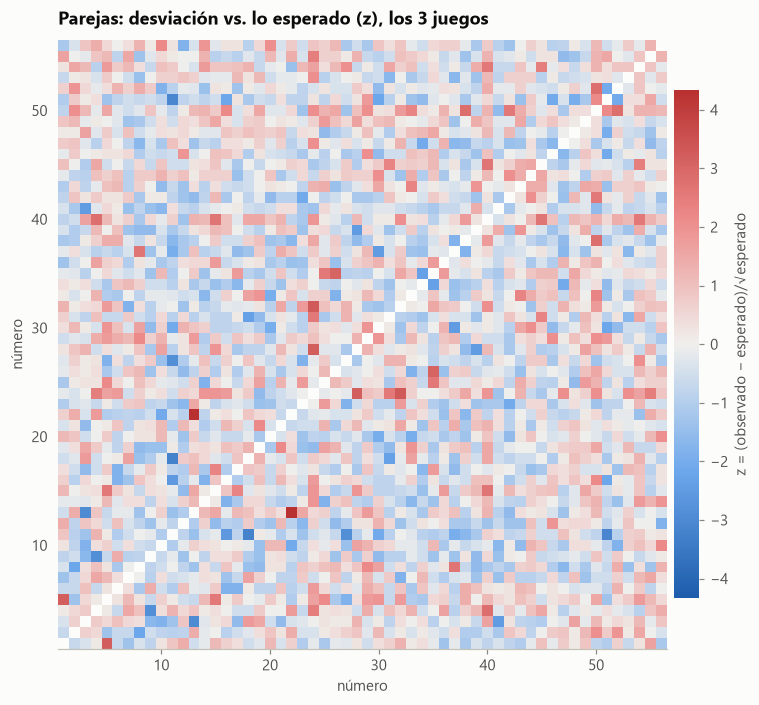

In [27]:
Z = (P - e_par) / np.sqrt(e_par)
np.fill_diagonal(Z, np.nan)
lim = np.nanmax(np.abs(Z))
fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(Z, cmap=DIVERGENTE, vmin=-lim, vmax=lim, origin="lower", extent=[0.5, N + 0.5, 0.5, N + 0.5])
ax.grid(False)
ax.set_title("Parejas: desviación vs. lo esperado (z), los 3 juegos")
ax.set_xlabel("número"); ax.set_ylabel("número")
cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.01)
cb.set_label("z = (observado − esperado)/√esperado", color=TINTA_2); cb.outline.set_visible(False)
guardar(fig, "08_parejas_heatmap")
plt.show()

**Lectura:** la pareja más frecuente (13–22, 95 veces contra 61 esperadas) llama la atención, pero entre 1,540 parejas posibles el máximo de una historia simulada suele ser parecido (p ≈ 0.06). La dispersión total de los conteos (7.5) es incluso un poco menor que la esperada (7.8). El heatmap parece ruido blanco porque lo es: no hay parejas "amigas".

## 10. Dependencia entre sorteos
Si los sorteos son independientes:
- Los números que se repiten del sorteo anterior siguen una **hipergeométrica** (en promedio 6·6/56 ≈ 0.64).
- Lo mismo entre Melate, Revancha y Revanchita del mismo concurso (son extracciones distintas).
- La serie de la *suma* no tiene autocorrelación.

In [28]:
def coincidencias(a, b):
    return np.array([len(set(x) & set(y)) for x, y in zip(a, b)])


hip = stats.hypergeom(N, K, K)
filas, dist = [], {}
for juego in JUEGOS:
    d = act[act.juego == juego].sort_values("concurso")[N_COLS].to_numpy()
    dist[f"{juego}: vs sorteo anterior"] = coincidencias(d[1:], d[:-1])
pivote = act.pivot(index="concurso", columns="juego", values=N_COLS)
for a, b in [("Melate", "Revancha"), ("Melate", "Revanchita"), ("Revancha", "Revanchita")]:
    sub = act[act.juego.isin([a, b])].pivot(index="concurso", columns="juego", values=N_COLS).dropna()
    xa = sub.xs(a, axis=1, level=1).to_numpy(int); xb = sub.xs(b, axis=1, level=1).to_numpy(int)
    dist[f"{a} vs {b} (mismo concurso)"] = coincidencias(xa, xb)

for k_, v in dist.items():
    o = np.bincount(np.minimum(v, 3), minlength=4)
    e = np.r_[hip.pmf([0, 1, 2]), hip.sf(2)] * len(v)
    chi, pv = stats.chisquare(o, e)
    filas.append({"comparación": k_, "pares": len(v), "coincidencias promedio": v.mean(), "esperado": hip.mean(),
                  "% con 0": (v == 0).mean() * 100, "% teórico 0": hip.pmf(0) * 100, "p-valor χ²": pv})
pd.DataFrame(filas).set_index("comparación").round(3)

,pares,coincidencias promedio,esperado,% con 0,% teórico 0,p-valor χ²
comparación,,,,,,
Melate: vs sorteo anterior,2184,0.658,0.643,48.947,48.942,0.158
Revancha: vs sorteo anterior,2184,0.614,0.643,50.229,48.942,0.278
Revanchita: vs sorteo anterior,1902,0.663,0.643,47.739,48.942,0.227
Melate vs Revancha (mismo concurso),2185,0.622,0.643,50.389,48.942,0.496
Melate vs Revanchita (mismo concurso),1903,0.662,0.643,47.399,48.942,0.521
Revancha vs Revanchita (mismo concurso),1903,0.648,0.643,48.135,48.942,0.751


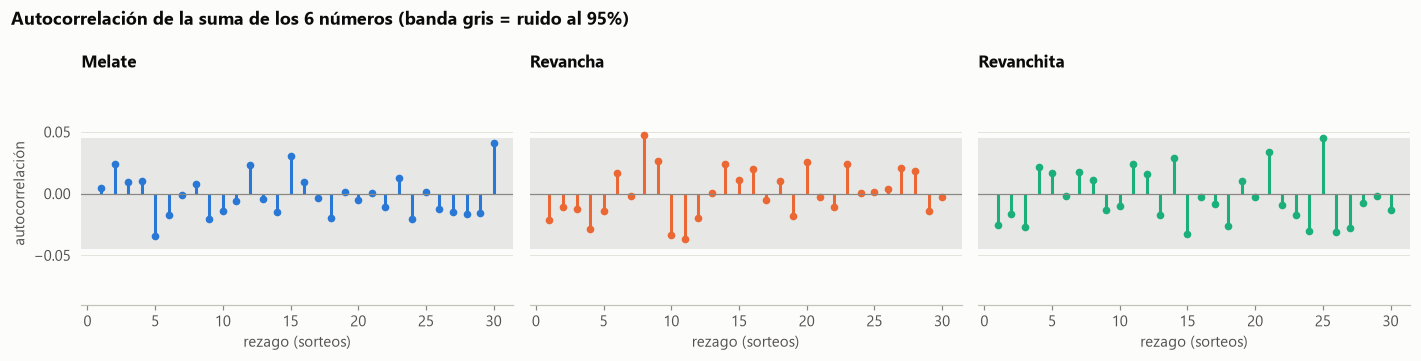

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3), sharey=True)
banda = 1.96 / np.sqrt(act.groupby("juego", observed=True).size().min())
for ax, juego in zip(axes, JUEGOS):
    s = act[act.juego == juego].sort_values("concurso")[N_COLS].sum(axis=1)
    r = acf(s, nlags=30, fft=True)[1:]
    ax.axhspan(-banda, banda, color=TEORICO, alpha=0.12, lw=0)
    ax.vlines(range(1, 31), 0, r, color=COLORES[juego], lw=2)
    ax.plot(range(1, 31), r, "o", color=COLORES[juego], ms=4)
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.set_ylim(-2 * banda, 2 * banda)
    ax.set_title(juego, fontsize=11); ax.set_xlabel("rezago (sorteos)")
axes[0].set_ylabel("autocorrelación")
fig.suptitle("Autocorrelación de la suma de los 6 números (banda gris = ruido al 95%)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
guardar(fig, "09_autocorrelacion_suma")
plt.show()

**Lectura:** el número de coincidencias con el sorteo anterior y entre juegos del mismo concurso sigue exactamente la hipergeométrica (~49% de las veces no se repite ningún número, como predice la teoría). La autocorrelación de la suma queda dentro de la banda de ruido en los 30 rezagos. **Los sorteos son independientes entre sí y entre juegos.**

## 11. ¿Se ha repetido alguna combinación ganadora?
Hay C(56,6) = 32,468,436 combinaciones posibles. Por la *paradoja del cumpleaños*, con T sorteos se esperan unas T²/(2·C) repeticiones.

In [30]:
C56 = comb(N, K)
combos = act[N_COLS].astype(str).agg("-".join, axis=1)
rep = combos.value_counts()
rep = rep[rep > 1]
print(f"Combinaciones del régimen vigente (3 juegos): {len(combos):,} | posibles: {C56:,} | "
      f"repeticiones esperadas: {len(combos) ** 2 / (2 * C56):.3f} | observadas: {len(rep)}")
if len(rep):
    display(act[combos.isin(rep.index)][["concurso", "fecha", "juego", *N_COLS]])

todas = df[N_COLS].astype(str).agg("-".join, axis=1)
rep_all = todas.value_counts()
rep_all = rep_all[rep_all > 1]
print(f"En todo el histórico (todos los rangos): {len(rep_all)} combinaciones repetidas")
if len(rep_all):
    display(df[todas.isin(rep_all.index)][["concurso", "fecha", "juego", *N_COLS]])

Combinaciones del régimen vigente (3 juegos): 6,273 | posibles: 32,468,436 | repeticiones esperadas: 0.606 | observadas: 2


,concurso,fecha,juego,n1,n2,n3,n4,n5,n6
3613,2311,2010-01-27,Revancha,5,7,18,26,28,33
3977,2452,2011-06-05,Revanchita,7,18,23,27,45,54
4132,2504,2011-12-04,Revancha,7,18,23,27,45,54
7660,3680,2022-12-18,Revancha,5,7,18,26,28,33


En todo el histórico (todos los rangos): 5 combinaciones repetidas


,concurso,fecha,juego,n1,n2,n3,n4,n5,n6
3,4,1984-09-09,Melate,8,12,15,18,20,34
1272,1141,1998-11-11,Melate,5,11,14,38,40,41
2894,1952,2006-08-20,Melate,11,16,19,22,25,47
2917,1963,2006-09-27,Revancha,5,11,14,38,40,41
3613,2311,2010-01-27,Revancha,5,7,18,26,28,33
3977,2452,2011-06-05,Revanchita,7,18,23,27,45,54
4132,2504,2011-12-04,Revancha,7,18,23,27,45,54
7660,3680,2022-12-18,Revancha,5,7,18,26,28,33
7670,3683,2022-12-25,Revanchita,11,16,19,22,25,47
8844,4075,2025-06-27,Melate,8,12,15,18,20,34


**Lectura:** en el régimen vigente se repitieron 2 combinaciones (ambas entre Revancha y Revanchita), contra 0.6 esperadas. Esto ocurre por azar ~12% de las veces, así que no es significativo. Curiosidad: la combinación **8-12-15-18-20-34** del concurso 4 (1984) volvió a salir en el Melate 4075 (2025), 41 años después.

## 12. Bolsa acumulada
Solo se grafican los sorteos con bolsa publicada (el sitio muestra $0 cuando no tiene el dato, y la cobertura es irregular). Antes de 1993 las cifras están en pesos viejos y se dividen entre 1,000.

Último sorteo con bolsa publicada: 2022-10-23 | descartados 3 valores < $100 mil (errores de captura)


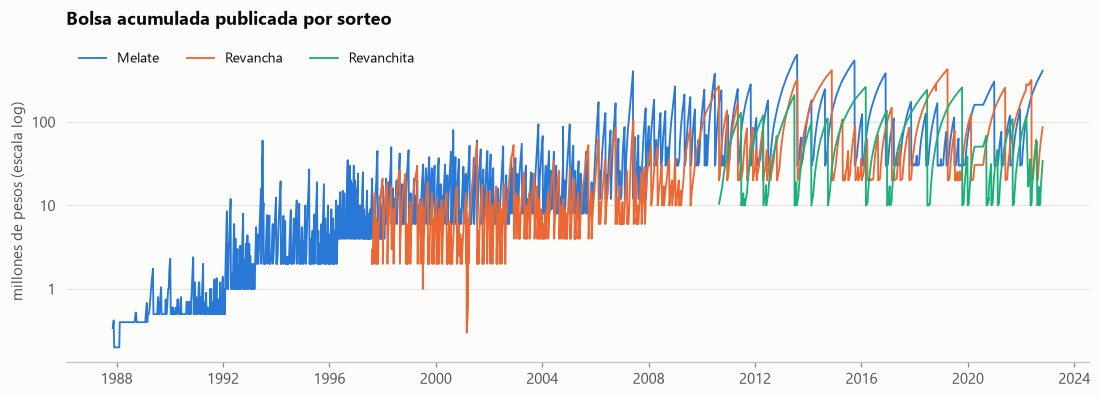

,concurso,fecha,juego,bolsa_mxn
4650,2677,2013-07-31,Melate,"$639,500,000"
4647,2676,2013-07-28,Melate,"$632,500,000"
4644,2675,2013-07-24,Melate,"$627,000,000"
4641,2674,2013-07-21,Melate,"$619,000,000"
4638,2673,2013-07-17,Melate,"$612,500,000"


In [31]:
b = df[df.bolsa.notna()].copy()
b["bolsa_mxn"] = np.where(b.fecha < "1993-01-01", b.bolsa / 1000, b.bolsa).astype(float)
atipicos = b[b.bolsa_mxn < 100_000]
b = b[b.bolsa_mxn >= 100_000]
print(f"Último sorteo con bolsa publicada: {b.fecha.max().date()} | descartados {len(atipicos)} valores < $100 mil (errores de captura)")
fig, ax = plt.subplots(figsize=(12, 3.8))
for juego in JUEGOS:
    s = b[b.juego == juego]
    ax.plot(s.fecha, s.bolsa_mxn / 1e6, color=COLORES[juego], lw=1.2, label=juego)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,g}"))
ax.set_ylabel("millones de pesos (escala log)")
ax.set_title("Bolsa acumulada publicada por sorteo")
ax.legend(ncols=3, loc="upper left")
guardar(fig, "10_bolsa")
plt.show()
top_b = b.nlargest(5, "bolsa_mxn")[["concurso", "fecha", "juego", "bolsa_mxn"]]
top_b.assign(bolsa_mxn=top_b.bolsa_mxn.map("${:,.0f}".format))

**Lectura:** la bolsa crece mientras nadie gana y se reinicia al haber ganador (el patrón de "dientes de sierra"). El máximo publicado fue de ~$640 millones (Melate, julio 2013). Como el dato se interrumpe a finales de 2022, no sirve para modelar el periodo reciente.

## 13. Estado actual de cada número (para referencia)

In [32]:
estado = []
for juego in JUEGOS:
    d = act[act.juego == juego].sort_values("concurso")
    ult = d.melt(id_vars="concurso", value_vars=N_COLS, value_name="num").groupby("num").concurso.max()
    f = frecuencias(d)
    estado.append(pd.DataFrame({"frecuencia": f, "atraso_actual": d.concurso.max() - ult.reindex(f.index)}).add_prefix(f"{juego}_"))
estado = pd.concat(estado, axis=1)
estado.to_csv(ROOT / "data" / "processed" / "estado_numeros.csv")
estado.sort_values("Melate_atraso_actual", ascending=False).head(15)

,Melate_frecuencia,Melate_atraso_actual,Revancha_frecuencia,Revancha_atraso_actual,Revanchita_frecuencia,Revanchita_atraso_actual
número,,,,,,
52,242,34,226,8,206,7
16,222,32,233,6,212,0
45,234,29,235,1,217,10
40,238,27,254,1,232,3
39,234,24,243,17,179,2
38,208,23,232,6,206,9
47,220,23,224,11,201,20
19,255,21,232,12,194,13
23,220,18,242,5,177,20


## 14. Conclusiones

1. **La base es confiable:** 9,441 sorteos validados, sin huecos (3 completados con otra fuente) y con los cambios de reglas identificados.
2. **El sorteo se comporta como un generador aleatorio justo** en todas las dimensiones probadas: frecuencias, atrasos, forma de la combinación, parejas, orden de extracción e independencia temporal y entre juegos.
3. **Consecuencia directa para el modelo predictivo:** no existe patrón aprendible. Un modelo (regresión, XGBoost, LSTM, etc.) entrenado para "predecir los próximos números" va a sobreajustar ruido y, evaluado honestamente, va a dar ~0.643 aciertos por jugada, igual que elegir al azar. La probabilidad de ganar el primer lugar es de 1 en 32,468,436 por combinación, se elija como se elija.

### ¿Qué sí puede aportar un modelo?
- **a) Un banco de pruebas riguroso.** Con el backtest de la sección 5 se puede evaluar cualquier modelo o "sistema" contra el azar con p-valores, en vez de confiar en aciertos anecdóticos.
- **b) Maximizar el *valor esperado* en lugar de la probabilidad.** No se puede ganar más seguido, pero sí ganar más cuando se gana: si se evitan combinaciones que mucha gente juega (fechas ≤31, patrones en el boleto, secuencias, números "de la suerte", combinaciones ganadoras anteriores), se comparten menos veces los premios. Esto requiere datos de **ganadores por categoría**, que habría que conseguir aparte.
- **c) Simulación de rentabilidad:** el valor esperado de un boleto según el tamaño de la bolsa, para saber en qué sorteos (si en alguno) el boleto se acerca a "valer lo que cuesta".